# ============================================
# Career Switch Prediction Project
# Models: KNN, Decision Tree, Neural Network (MLP)
# Includes: Preprocessing + Unsupervised Learning (K-Means) + Evaluation
# ============================================

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)

In [3]:
!mkdir -p data


In [10]:
# Load dataset from local repository path
dataset = pd.read_csv("data/Career_Switch_Prediction_Dataset.csv")

print(dataset.head())

   enrollee_id      city  city_development_index gender  \
0         8949  city_103                   0.920   Male   
1        29725   city_40                   0.776   Male   
2        11561   city_21                   0.624    NaN   
3        33241  city_115                   0.789    NaN   
4          666  city_162                   0.767   Male   

       relevent_experience enrolled_university education_level  \
0  Has relevent experience       no_enrollment        Graduate   
1   No relevent experience       no_enrollment        Graduate   
2   No relevent experience    Full time course        Graduate   
3   No relevent experience                 NaN        Graduate   
4  Has relevent experience       no_enrollment         Masters   

  major_discipline experience company_size    company_type last_new_job  \
0             STEM        >20          NaN             NaN            1   
1             STEM         15        50-99         Pvt Ltd           >4   
2             STEM     

In [ ]:
dataset = pd.read_csv(new_link)
print("Dataset Loaded")
print("Shape:", dataset.shape)
display(dataset.head())

Dataset Loaded
Shape: (5000, 14)


,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,will_change_career
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,0,83,0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,0,52,1
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0


Basic Inspection

In [ ]:
display(dataset.describe())
dataset.info()

,enrollee_id,city_development_index,training_hours,will_change_career
count,5000.000000,5000.000000,5000.000000,5000.000000
mean,17022.883000,0.829410,65.027200,0.252400
std,9656.969716,0.122429,59.946693,0.434433
min,7.000000,0.448000,1.000000,0.000000
25%,8736.500000,0.743000,23.000000,0.000000
50%,17068.000000,0.903000,47.000000,0.000000
75%,25389.250000,0.920000,88.000000,1.000000
max,33380.000000,0.949000,336.000000,1.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             5000 non-null   int64  
 1   city                    5000 non-null   object 
 2   city_development_index  5000 non-null   float64
 3   gender                  3887 non-null   object 
 4   relevent_experience     5000 non-null   object 
 5   enrolled_university     4893 non-null   object 
 6   education_level         4882 non-null   object 
 7   major_discipline        4276 non-null   object 
 8   experience              4989 non-null   object 
 9   company_size            3429 non-null   object 
 10  company_type            3379 non-null   object 
 11  last_new_job            4896 non-null   object 
 12  training_hours          5000 non-null   int64  
 13  will_change_career      5000 non-null   int64  
dtypes: float64(1), int64(3), object(10)
memo

## Exploratory Data Analysis (EDA)


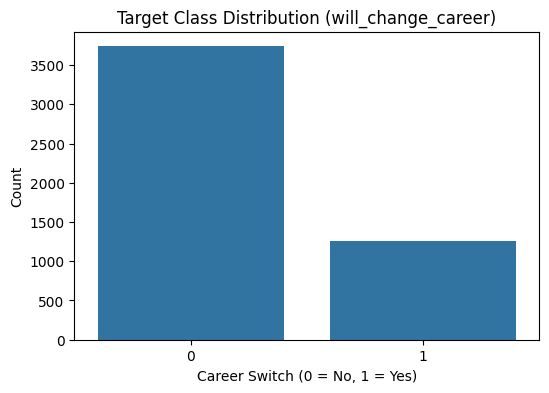

,count
will_change_career,
0,3738
1,1262


In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x=dataset['will_change_career'])
plt.title("Target Class Distribution (will_change_career)")
plt.xlabel("Career Switch (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

# Numerical confirmation
dataset['will_change_career'].value_counts()


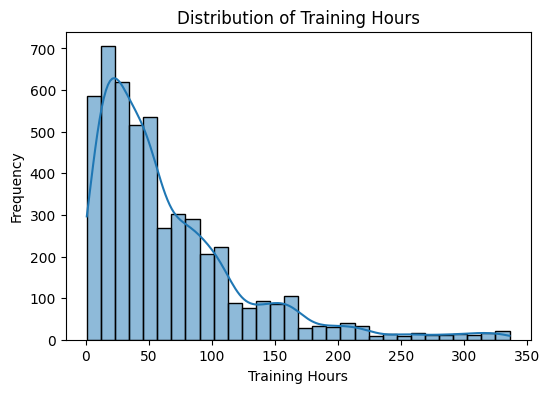

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(dataset['training_hours'], bins=30, kde=True)
plt.title("Distribution of Training Hours")
plt.xlabel("Training Hours")
plt.ylabel("Frequency")
plt.show()


Relationship between Feature and Target

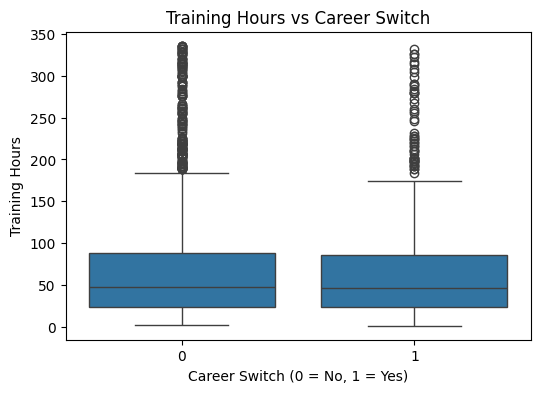

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(
    x='will_change_career',
    y='training_hours',
    data=dataset
)
plt.title("Training Hours vs Career Switch")
plt.xlabel("Career Switch (0 = No, 1 = Yes)")
plt.ylabel("Training Hours")
plt.show()


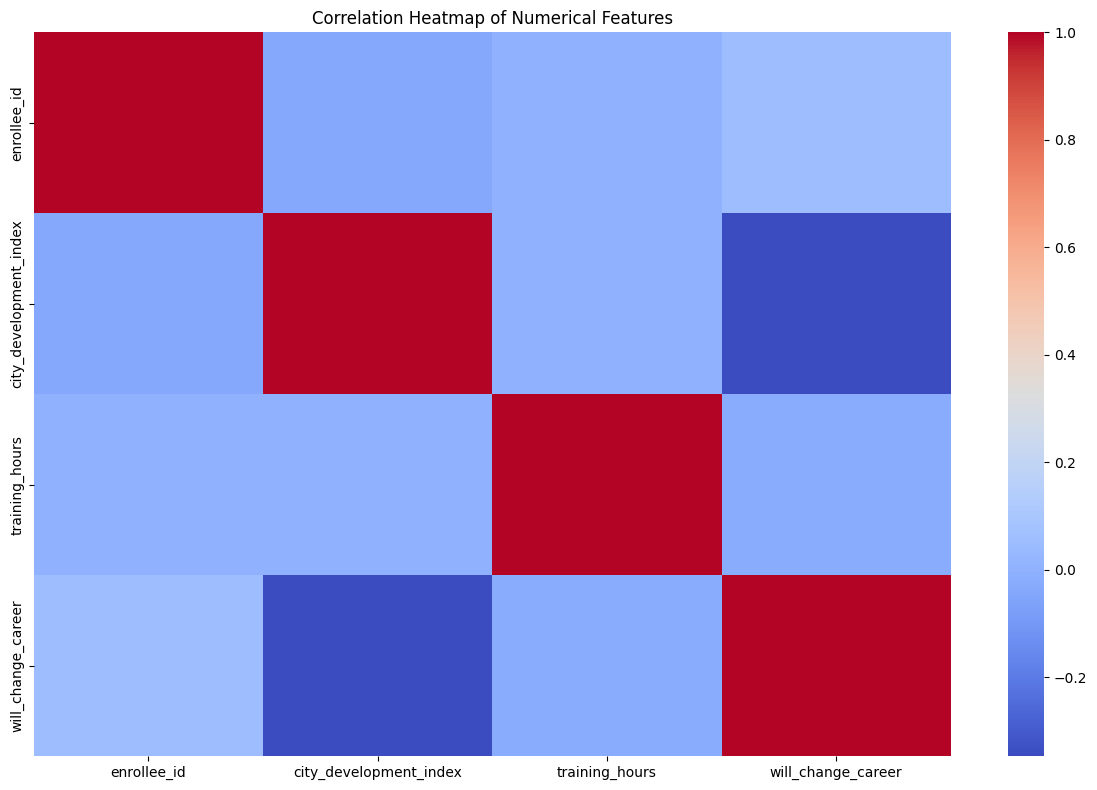

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(
    dataset.corr(numeric_only=True),
    cmap='coolwarm'
)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


#Missing values check

In [ ]:
print("\nMissing Values (Before):")
display(dataset.isnull().sum().sort_values(ascending=False).head(20))



Missing Values (Before):


,0
company_type,1621
company_size,1571
gender,1113
major_discipline,724
education_level,118
enrolled_university,107
last_new_job,104
experience,11
enrollee_id,0
city,0


Handle Missing Values (Imputation)

In [ ]:
num_cols = dataset.select_dtypes(include=['int64','float64']).columns
cat_cols = dataset.select_dtypes(include=['object']).columns

# Numerical imputation
num_imputer = SimpleImputer(strategy='mean')
dataset[num_cols] = num_imputer.fit_transform(dataset[num_cols])
# Categorical imputation (only if categorical columns exist)
if len(cat_cols) > 0:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    dataset[cat_cols] = cat_imputer.fit_transform(dataset[cat_cols])

print("\nMissing Values (After):")
display(dataset.isnull().sum().sort_values(ascending=False).head(20))



Missing Values (After):


,0
enrollee_id,0
city,0
city_development_index,0
gender,0
relevent_experience,0
enrolled_university,0
education_level,0
major_discipline,0
experience,0
company_size,0


Remove Duplicates

In [ ]:
before = dataset.shape[0]
dataset.drop_duplicates(inplace=True)
after = dataset.shape[0]
print(f"\n Duplicates removed: {before - after}")
print("Shape after removing duplicates:", dataset.shape)



 Duplicates removed: 0
Shape after removing duplicates: (5000, 14)


Encode Categorical

In [ ]:
cat_cols = dataset.select_dtypes(include=['object']).columns
if len(cat_cols) > 0:
    dataset = pd.get_dummies(dataset, columns=cat_cols, drop_first=True)
    print("\n One-hot encoding applied.")
else:
    print("\n No categorical columns to encode.")

print("Shape after encoding:", dataset.shape)


 No categorical columns to encode.
Shape after encoding: (5000, 168)


Target & Features

In [ ]:
target_col = "will_change_career"

# Drop ID column to reduce noise
if "enrollee_id" in dataset.columns:
    dataset.drop("enrollee_id", axis=1, inplace=True)
    print("\n Dropped enrollee_id (identifier column).")

X = dataset.drop(target_col, axis=1)
y = dataset[target_col]

print("\nTarget distribution:")
display(y.value_counts())


 Dropped enrollee_id (identifier column).

Target distribution:


,count
will_change_career,
0,3738
1,1262


Correlation with Target


Top correlations with target:


,will_change_career
will_change_career,1.000000
city_city_21,0.322971
company_size_50-99,0.174482
relevent_experience_No relevent experience,0.112887
city_city_11,0.111804
experience_<1,0.081159
experience_3,0.069924
city_city_101,0.069367
experience_4,0.067737
company_type_Pvt Ltd,0.064673


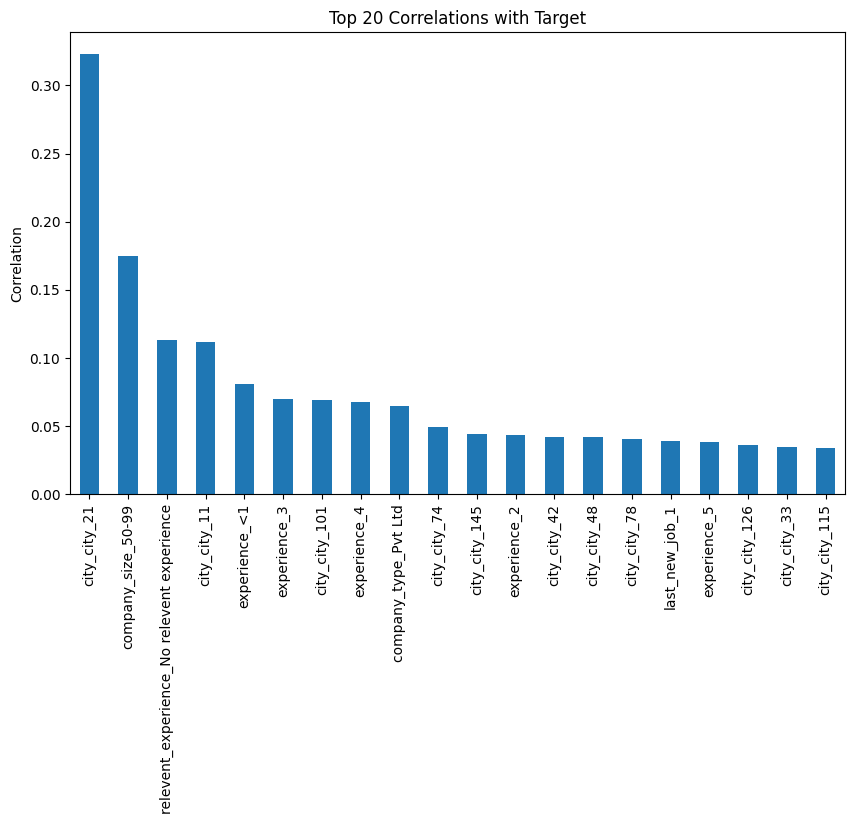

In [ ]:
# ---------- Correlation with Target (Top 20) ----------
corr_with_target = dataset.corr(numeric_only=True)[target_col].sort_values(ascending=False)
print("\nTop correlations with target:")
display(corr_with_target.head(15))

plt.figure(figsize=(10,6))
corr_with_target.drop(target_col).head(20).plot(kind='bar')
plt.title("Top 20 Correlations with Target")
plt.ylabel("Correlation")
plt.show()

# ---------- Train-Test Split (IMPORTANT: split before scaling to avoid leakage) ----------
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


Feature Scaling

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print("\n Train/Test Split + Scaling Done")
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


 Train/Test Split + Scaling Done
Train shape: (4000, 166) Test shape: (1000, 166)


 UNSUPERVISED LEARNING: K-Means Clustering

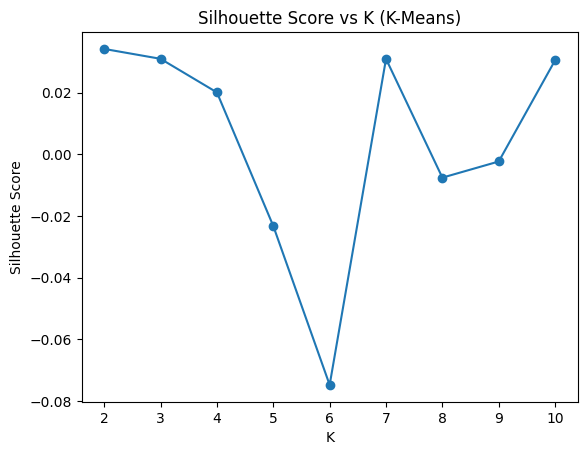

✅ Best K (by silhouette): 2

Cluster counts (Train):
1    2274
0    1726
Name: count, dtype: int64


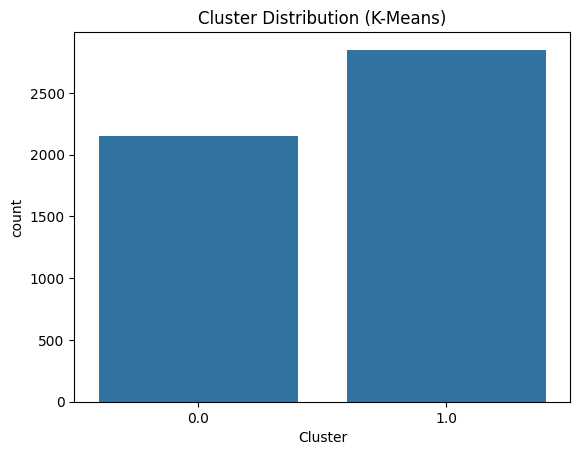

In [ ]:
# ---------- Choose K using Silhouette Score // for numerical ----------
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_train)  # using train data
    sil_scores.append(silhouette_score(X_train, labels))

plt.plot(list(K_range), sil_scores, marker='o')
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K (K-Means)")
plt.show()

best_k = list(K_range)[np.argmax(sil_scores)]
print(" Best K (by silhouette):", best_k)

# ---------- Fit KMeans using best K ----------
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
train_clusters = kmeans.fit_predict(X_train)
test_clusters = kmeans.predict(X_test)

print("\nCluster counts (Train):")
print(pd.Series(train_clusters).value_counts())

# Add cluster labels to original dataset rows (optional)
dataset.loc[X_train_raw.index, "Cluster"] = train_clusters
dataset.loc[X_test_raw.index, "Cluster"] = test_clusters

sns.countplot(x="Cluster", data=dataset)
plt.title("Cluster Distribution (K-Means)")
plt.show()


Visualization of Clusters

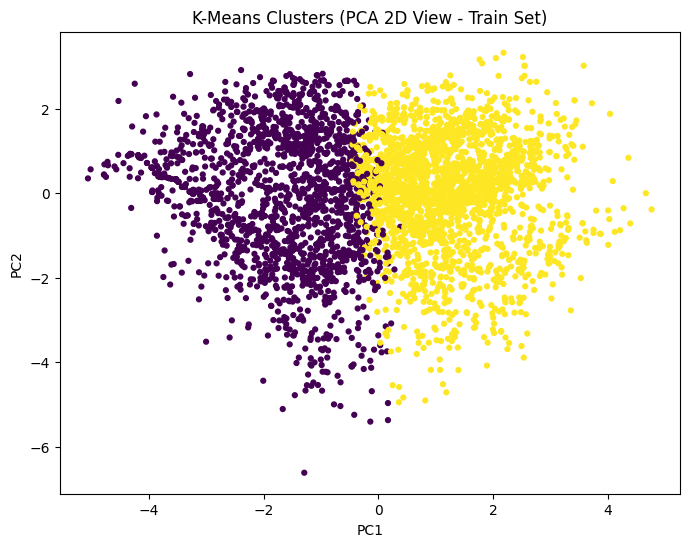

In [ ]:
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train)

plt.figure(figsize=(8,6))
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], c=train_clusters, s=12)
plt.title("K-Means Clusters (PCA 2D View - Train Set)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

SUPERVISED LEARNING

In [ ]:
# ---------- KNN ----------
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)
knn_prob = knn.predict_proba(X_test)[:, 1]

# ---------- Decision Tree ----------
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_prob = dt.predict_proba(X_test)[:, 1]

# ---------- Neural Network (MLP) ----------
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    max_iter=500,
    random_state=42
)
mlp.fit(X_train, y_train)
mlp_pred = mlp.predict(X_test)
mlp_prob = mlp.predict_proba(X_test)[:, 1]

 EVALUATION & COMPARISON

In [ ]:
# ---------- Evaluation Function ----------
def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    pre = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1  = f1_score(y_true, y_pred, zero_division=0)

    print(f"\n=== {name} ===")
    print("Accuracy :", acc)
    print("Precision:", pre)
    print("Recall   :", rec)
    print("F1-score :", f1)
    print("\nClassification Report:\n", classification_report(y_true, y_pred, zero_division=0))
    return acc, pre, rec, f1

results = {}
results["KNN"] = evaluate_model("KNN", y_test, knn_pred)
results["Decision Tree"] = evaluate_model("Decision Tree", y_test, dt_pred)
results["MLP"] = evaluate_model("MLP", y_test, mlp_pred)



=== KNN ===
Accuracy : 0.744
Precision: 0.4908256880733945
Recall   : 0.4246031746031746
F1-score : 0.4553191489361702

Classification Report:
               precision    recall  f1-score   support

         0.0       0.81      0.85      0.83       748
         1.0       0.49      0.42      0.46       252

    accuracy                           0.74      1000
   macro avg       0.65      0.64      0.64      1000
weighted avg       0.73      0.74      0.74      1000


=== Decision Tree ===
Accuracy : 0.786
Precision: 0.6055555555555555
Recall   : 0.43253968253968256
F1-score : 0.5046296296296297

Classification Report:
               precision    recall  f1-score   support

         0.0       0.83      0.91      0.86       748
         1.0       0.61      0.43      0.50       252

    accuracy                           0.79      1000
   macro avg       0.72      0.67      0.68      1000
weighted avg       0.77      0.79      0.77      1000


=== MLP ===
Accuracy : 0.71
Precision: 0.429

 Confusion Matrices

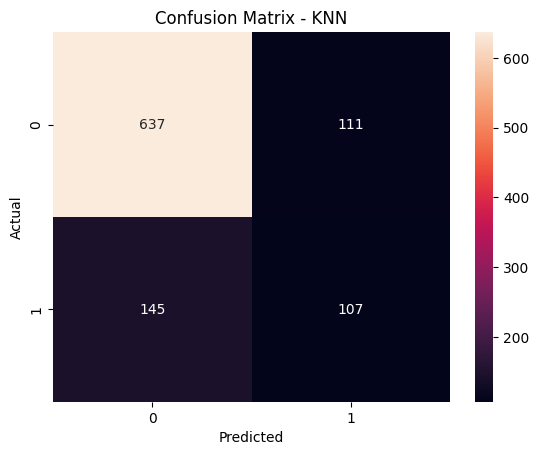

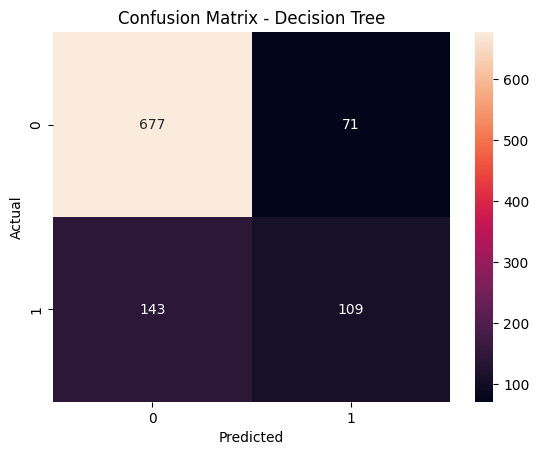

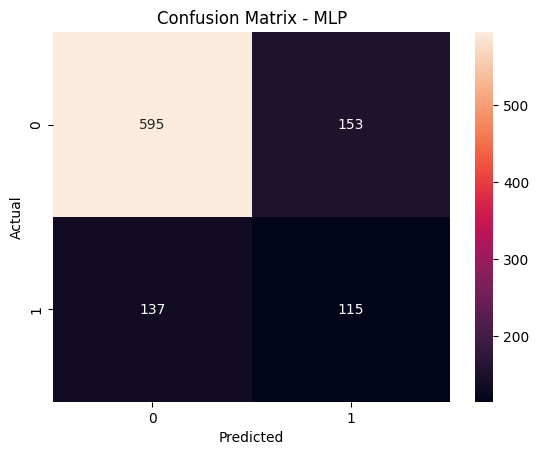

In [ ]:
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_cm(y_test, knn_pred, "Confusion Matrix - KNN")
plot_cm(y_test, dt_pred, "Confusion Matrix - Decision Tree")
plot_cm(y_test, mlp_pred, "Confusion Matrix - MLP")


ROC Curve + AUC

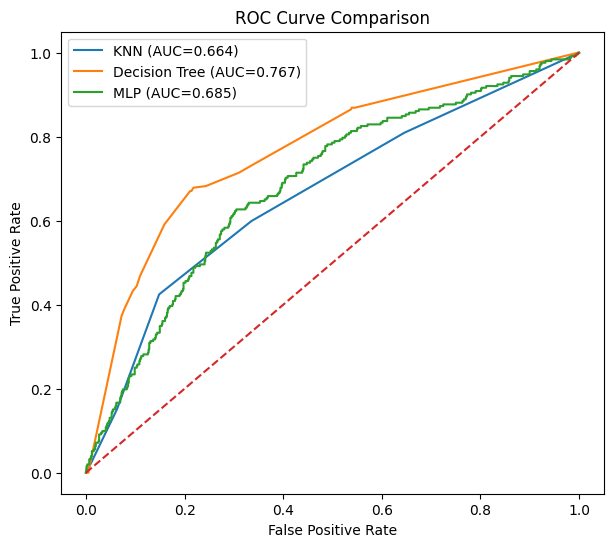

In [ ]:
def plot_roc(name, y_true, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")
    return roc_auc

plt.figure(figsize=(7,6))
auc_knn = plot_roc("KNN", y_test, knn_prob)
auc_dt  = plot_roc("Decision Tree", y_test, dt_prob)
auc_mlp = plot_roc("MLP", y_test, mlp_prob)

plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

 Results DataFrame

In [ ]:
results_df = pd.DataFrame({
    "accuracy": [results["KNN"][0], results["Decision Tree"][0], results["MLP"][0]],
    "precision": [results["KNN"][1], results["Decision Tree"][1], results["MLP"][1]],
    "recall": [results["KNN"][2], results["Decision Tree"][2], results["MLP"][2]],
    "f1_score": [results["KNN"][3], results["Decision Tree"][3], results["MLP"][3]],
    "auc_score": [auc_knn, auc_dt, auc_mlp]
}, index=["KNN", "Decision Tree", "MLP"])

print("\n=== MODEL COMPARISON TABLE ===")
display(results_df)


=== MODEL COMPARISON TABLE ===


,accuracy,precision,recall,f1_score,auc_score
KNN,0.744,0.490826,0.424603,0.455319,0.664110
Decision Tree,0.786,0.605556,0.432540,0.504630,0.767356
MLP,0.710,0.429104,0.456349,0.442308,0.684991


Accuracy Bar Chart

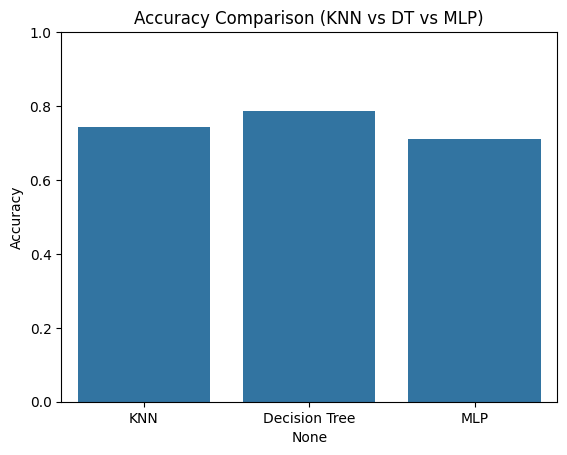

=== FINAL CONCLUSIONS ===
 BEST MODEL OVERALL: Decision Tree
   Based on F1 Score : 0.5046
   Accuracy         : 0.7860
   AUC Score        : 0.7674

Model Rankings by Different Metrics:
• Best F1 Score    : Decision Tree
• Best Accuracy    : Decision Tree
• Best AUC Score   : Decision Tree

===DOMAIN INSIGHTS ===
✓ Dataset analyzed: 5,000 professionals
✓ Overall career switch rate: 25.2%
✓ The model can predict career switching behavior with 78.6% accuracy


In [ ]:
sns.barplot(x=results_df.index, y=results_df["accuracy"])
plt.ylim(0,1)
plt.title("Accuracy Comparison (KNN vs DT vs MLP)")
plt.ylabel("Accuracy")
plt.show()

# ---------- INAL CONCLUSIONS (Sample-style, adapted) ----------
print("=== FINAL CONCLUSIONS ===")

best_model_f1 = results_df['f1_score'].idxmax()
best_model_accuracy = results_df['accuracy'].idxmax()
best_model_auc = results_df['auc_score'].idxmax()

print(f" BEST MODEL OVERALL: {best_model_f1}")
print(f"   Based on F1 Score : {results_df.loc[best_model_f1, 'f1_score']:.4f}")
print(f"   Accuracy         : {results_df.loc[best_model_f1, 'accuracy']:.4f}")
print(f"   AUC Score        : {results_df.loc[best_model_f1, 'auc_score']:.4f}")

print("\nModel Rankings by Different Metrics:")
print(f"• Best F1 Score    : {best_model_f1}")
print(f"• Best Accuracy    : {best_model_accuracy}")
print(f"• Best AUC Score   : {best_model_auc}")

print("\n===DOMAIN INSIGHTS ===")
print(f"✓ Dataset analyzed: {len(dataset):,} professionals")
print(f"✓ Overall career switch rate: {y.mean():.1%}")
print(f"✓ The model can predict career switching behavior with "
      f"{results_df.loc[best_model_f1, 'accuracy']:.1%} accuracy")

ROC curve is showing how well the model distinguishes between switchers and non-switchers at different thresholds, and AUC measures the overall discriminative power of the model.